In [31]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore
from sklearn.preprocessing import MinMaxScaler

In [32]:
# Load dataset
df = pd.read_csv("data_2.csv")

print(df)
print(df.isnull().sum())


    Name   Age  GPA  Test_Score  Attendance
0   Amit  18.0  8.1          78        85.0
1   Neha  19.0  7.8          82        90.0
2  Rahul   NaN  9.0          91        88.0
3  Priya  20.0  8.5          85         NaN
4  Karan  21.0  7.2          76        76.0
5  Sneha  19.0  8.9          88        92.0
6  Rohit  18.0  3.5         620        87.0
7  Pooja  20.0  8.0          80        89.0
8  Arjun  50.0  9.5          92       900.0
9  Kavya  19.0  8.3          79        84.0
Name          0
Age           1
GPA           0
Test_Score    0
Attendance    1
dtype: int64


In [33]:
# Fill missing values
df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Attendance'] = df['Attendance'].fillna(df['Attendance'].median())

print(df)


    Name        Age  GPA  Test_Score  Attendance
0   Amit  18.000000  8.1          78        85.0
1   Neha  19.000000  7.8          82        90.0
2  Rahul  22.666667  9.0          91        88.0
3  Priya  20.000000  8.5          85        88.0
4  Karan  21.000000  7.2          76        76.0
5  Sneha  19.000000  8.9          88        92.0
6  Rohit  18.000000  3.5         620        87.0
7  Pooja  20.000000  8.0          80        89.0
8  Arjun  50.000000  9.5          92       900.0
9  Kavya  19.000000  8.3          79        84.0


In [34]:
# Statistical summary
print(df.describe())


             Age        GPA  Test_Score  Attendance
count  10.000000  10.000000   10.000000   10.000000
mean   22.666667   7.880000  137.100000  167.900000
std     9.706813   1.673187  169.762874  257.270912
min    18.000000   3.500000   76.000000   76.000000
25%    19.000000   7.850000   79.250000   85.500000
50%    19.500000   8.200000   83.500000   88.000000
75%    20.750000   8.800000   90.250000   89.750000
max    50.000000   9.500000  620.000000  900.000000


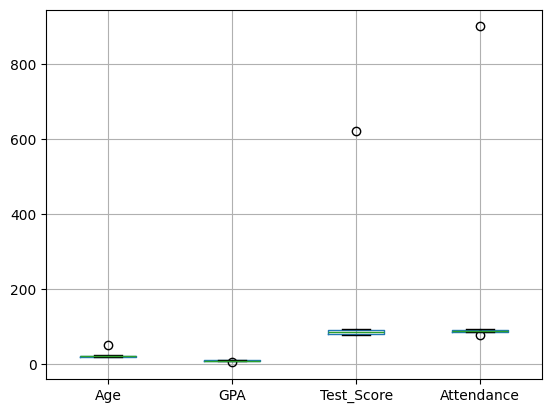

In [35]:
# Boxplot for outliers
df[['Age','GPA','Test_Score','Attendance']].boxplot()

plt.show()


In [36]:
# Remove outliers
z = np.abs(zscore(df[['Age','GPA','Test_Score','Attendance']]))

df = df[(z < 2.5).all(axis=1)]

print(df)


    Name        Age  GPA  Test_Score  Attendance
0   Amit  18.000000  8.1          78        85.0
1   Neha  19.000000  7.8          82        90.0
2  Rahul  22.666667  9.0          91        88.0
3  Priya  20.000000  8.5          85        88.0
4  Karan  21.000000  7.2          76        76.0
5  Sneha  19.000000  8.9          88        92.0
7  Pooja  20.000000  8.0          80        89.0
9  Kavya  19.000000  8.3          79        84.0


In [37]:
# Normalize data
scaler = MinMaxScaler()

df[['Age','GPA','Test_Score','Attendance']] = scaler.fit_transform(
    df[['Age','GPA','Test_Score','Attendance']]
)

print(df)


    Name       Age       GPA  Test_Score  Attendance
0   Amit  0.000000  0.500000    0.133333      0.5625
1   Neha  0.214286  0.333333    0.400000      0.8750
2  Rahul  1.000000  1.000000    1.000000      0.7500
3  Priya  0.428571  0.722222    0.600000      0.7500
4  Karan  0.642857  0.000000    0.000000      0.0000
5  Sneha  0.214286  0.944444    0.800000      1.0000
7  Pooja  0.428571  0.444444    0.266667      0.8125
9  Kavya  0.214286  0.611111    0.200000      0.5000


In [38]:
# Check skewness
print(df[['Age','GPA','Test_Score','Attendance']].skew())


Age           1.009749
GPA          -0.346064
Test_Score    0.597254
Attendance   -1.477838
dtype: float64
